# Lab 12 — CNN ด้วย PyTorch บน MNIST
### LeNet-5 in PyTorch: Dataset/DataLoader, training loop, evaluation, filters, augmentation, classic architectures

**กลุ่ม:** E CNN · **อ่านคู่กับสไลด์หน้า:** 199-210 · **เวลาโดยประมาณ:** 120 นาที · **Dataset:** MNIST train ≈10,000 ภาพ (limit=10000 → 9,999 จากการปัดเศษแบบ stratified) / test 2,000 ภาพ (ตั้ง env `NNLAB_FAST=1` → 3,000 ภาพ, 1 epoch)

**ควรทำมาก่อน:** Lab 11 (convolution, pooling, layout `(N, C, H, W)`) และ Lab 10 (confusion matrix, micro/macro) — training loop ของ torch เคยเห็นใน lab ก่อนหน้าแล้ว

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. เตรียมภาพ MNIST เป็น tensor `(m, 1, 28, 28)` และป้อนเป็น mini-batch ด้วย `TensorDataset` / `DataLoader`
2. เขียน LeNet-5 เป็น `nn.Module` เอง เดิน shape ผ่านทุกชั้น และนับ parameter ได้ (~60k ตามสไลด์ p.202)
3. เขียน training loop ของ PyTorch ด้วยมือ (zero_grad → forward → loss → backward → step) และอธิบายได้ว่าทำไม `CrossEntropyLoss` รับ logits กับ label เป็นเลข class
4. ประเมินผลด้วย confusion matrix 10×10 และ micro/macro จาก lab10, ดู filter กับ feature map ที่โมเดลเรียนได้, และทำ data augmentation ที่เหมาะกับตัวเลข
5. รู้จัก AlexNet / VGG-16 / ResNet และอธิบายได้ว่า skip connection ของ residual block ช่วยอะไร; บันทึกและโหลดโมเดลกลับมาใช้ได้

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)
lab นี้ใช้ PyTorch เต็มตัว — `torch.manual_seed(463)` คุมตัวเลขสุ่มฝั่ง torch (ค่าเริ่มต้นของ weight, การสลับ batch) และ `FAST` ลดขนาดข้อมูลถ้าตั้ง `NNLAB_FAST=1` ไว้

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import os, torch
from torch import nn
import torch.nn.functional as F
from torchvision import transforms
torch.manual_seed(463)
FAST = bool(os.environ.get("NNLAB_FAST"))
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ / คำ | ความหมาย | ที่มา |
|---|---|---|
| `(N, C, H, W)` | layout ของ tensor ภาพใน torch: batch × channel × สูง × กว้าง — MNIST คือ `(N, 1, 28, 28)` | lab11 ขั้นที่ 6 |
| **logits** | output ของชั้นสุดท้าย `(N, 10)` **ก่อน** softmax — โมเดล torch คืน logits และให้ loss function ทำ softmax เอง | p.199 (Softmax) |
| **epoch / mini-batch** | 1 epoch = วนครบทุกภาพใน training set 1 รอบ แบ่งเป็น mini-batch ละ 64 ภาพ | lab08 |
| `state_dict` | dict {ชื่อ parameter → tensor} ของโมเดล — สิ่งที่บันทึกลงไฟล์ | ขั้นที่ 8 |
| **augmentation** | สร้างภาพใหม่จากภาพเดิมด้วยการหมุน/เลื่อน/ตัด เพื่อให้ข้อมูลเทรน "เหมือนมีมากขึ้น" | p.208-210 |

## ขั้นที่ 1 · เตรียมข้อมูล MNIST เป็น tensor และ DataLoader
MNIST มีภาพลายมือเลข 0-9 ขนาด 28×28 grayscale 60,000 ภาพสำหรับเทรนและ 10,000 ภาพสำหรับทดสอบ
ในห้องเรียนเราใช้ subset (≈10,000 / 2,000 ภาพ สุ่มแบบ stratified โดย `load_mnist(limit=...)`) เพื่อให้เทรนบน CPU เสร็จในไม่กี่วินาที
`load_mnist` คืน `uint8 (m, 28, 28)` เหมือน lab11 — cell นี้โหลด แสดง 10 ภาพแรกพร้อม label และนับจำนวนต่อ class (ต้องใกล้เคียงกันทุก class)

train (9999, 28, 28) uint8 | test (2000, 28, 28) | FAST = False | epochs = 2
จำนวนต่อ class (train): [ 987 1124  993 1022  974  903  986 1044  975  991]
จำนวนต่อ class (test) : [196 227 206 202 196 178 192 206 195 202]


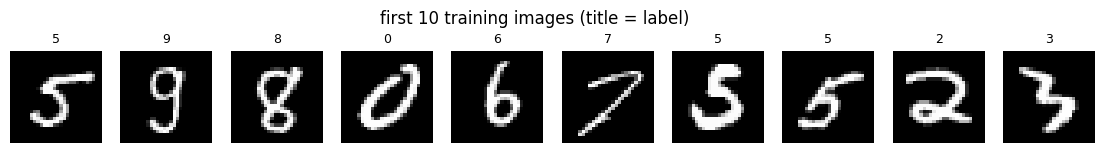

In [2]:
from nnlab.data import load_mnist
from nnlab.plotting import show_images

LIMIT_TRAIN, EPOCHS = (3000, 1) if FAST else (10000, 2)
Xtr_u8, ytr = load_mnist(train=True,  limit=LIMIT_TRAIN)   # Xtr_u8: (m, 28, 28) uint8 | ytr: (m,)
Xte_u8, yte = load_mnist(train=False, limit=2000)          # Xte_u8: (2000, 28, 28) uint8 | yte: (2000,)
print("train", Xtr_u8.shape, Xtr_u8.dtype, "| test", Xte_u8.shape, "| FAST =", FAST, "| epochs =", EPOCHS)
print("จำนวนต่อ class (train):", np.bincount(ytr))
print("จำนวนต่อ class (test) :", np.bincount(yte))
show_images(Xtr_u8, ytr, n=10, title="first 10 training images (title = label)")
plt.show()

torch ต้องการ 3 อย่าง: (1) `float32` ช่วง [0, 1] — หาร 255 (2) layout `(N, C, H, W)` — เพิ่มมิติ channel ด้วย `[:, None, :, :]` (3) label เป็น `int64` (`torch.long`) เพราะ `CrossEntropyLoss` ใช้ label เป็น index ของ class
`TensorDataset` จับคู่ (ภาพ, label) ทีละ sample และ `DataLoader` หั่นเป็น mini-batch ละ 64 พร้อมสลับลำดับทุก epoch (`shuffle=True`) — เราส่ง `generator` ที่ตั้ง seed ไว้ให้ลำดับสลับทำซ้ำได้
cell นี้ดึงมา 1 batch เพื่อดู shape: `xb` ต้องเป็น `(64, 1, 28, 28)` และ `yb` เป็น `(64,)`

In [3]:
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(Xtr_u8, dtype=torch.float32)[:, None, :, :] / 255.0   # X_train: (m, 1, 28, 28) float32 [0, 1]
X_test  = torch.tensor(Xte_u8, dtype=torch.float32)[:, None, :, :] / 255.0   # X_test : (2000, 1, 28, 28)
y_train = torch.tensor(ytr, dtype=torch.long)                                 # y_train: (m,) int64
y_test  = torch.tensor(yte, dtype=torch.long)                                 # y_test : (2000,)
print("X_train", tuple(X_train.shape), X_train.dtype, "| ค่า", float(X_train.min()), "-", float(X_train.max()))
print("y_train", tuple(y_train.shape), y_train.dtype)

train_ds = TensorDataset(X_train, y_train)           # train_ds[i] → (ภาพ (1, 28, 28), label)
test_ds  = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(463))
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)   # test ไม่ต้องสลับ และ batch ใหญ่ได้ (ไม่มี backward)
img, label = train_ds[0]
print("train_ds[0] → ภาพ", tuple(img.shape), "label", int(label), "| len(train_ds) =", len(train_ds), "→", len(train_loader), "batch ต่อ epoch")

xb, yb = next(iter(train_loader))                    # xb: (64, 1, 28, 28) | yb: (64,)
print("หนึ่ง batch: xb", tuple(xb.shape), xb.dtype, "| yb", tuple(yb.shape), yb.dtype, "| label 10 ตัวแรก", yb[:10].tolist())

X_train (9999, 1, 28, 28) torch.float32 | ค่า 0.0 - 1.0
y_train (9999,) torch.int64
train_ds[0] → ภาพ (1, 28, 28) label 5 | len(train_ds) = 9999 → 157 batch ต่อ epoch


หนึ่ง batch: xb (64, 1, 28, 28) torch.float32 | yb (64,) torch.int64 | label 10 ตัวแรก [5, 1, 8, 7, 3, 4, 7, 0, 1, 3]


## ขั้นที่ 2 · LeNet-5 เป็น `nn.Module` (สไลด์ p.199-202)
สถาปัตยกรรม (p.199): CONV1 ($f=5$, 6 filter) → POOL → CONV2 ($f=5$, 16 filter) → POOL → flatten 400 → FC 120 → FC 84 → 10 output
สไลด์ใช้ input 32×32 แต่ MNIST คือ 28×28 — เราใส่ `padding=2` ที่ CONV1 ให้เสมือน 32×32 (28 + 2·2 − 5 + 1 = 28) ทุก shape หลังจากนั้นจึงตรงกับสไลด์ (14×14×6 → 10×10×16 → 5×5×16 → 400)
ใช้ ReLU กับ max pooling ตาม p.199 (LeNet-5 ดั้งเดิม p.202 ใช้ average pooling — ลองเป็นแบบฝึกหัด)

`nn.Module` มี 2 ส่วน: `__init__` ประกาศชั้นที่มี parameter (Conv2d, Linear) และ `forward` บอกลำดับการคำนวณ — torch สร้าง backward ให้เองจาก forward
`nn.Conv2d(in_channels, out_channels, kernel_size, padding)` คือ `conv2d_volume` ของ lab11 ที่ weight เป็น parameter เรียนได้ shape `(n_F, C, f, f)`
สังเกตว่า `forward` คืน **logits** — ไม่มี softmax (ดูขั้นที่ 3 ว่าทำไม)

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

In [4]:
class LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)   # (N, 1, 28, 28) → (N, 6, 28, 28)   f=5, p=2, n_F=6
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)        # ครึ่งหนึ่ง — ไม่มี parameter จึงใช้ซ้ำได้สองที่
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)              # (N, 6, 14, 14) → (N, 16, 10, 10)  f=5, p=0, n_F=16
        self.fc1   = nn.Linear(16 * 5 * 5, 120)                   # 400 → 120   (W[3] = 120×400 สไลด์ p.199)
        self.fc2   = nn.Linear(120, 84)                           # 120 → 84    (W[4] = 84×120)
        self.fc3   = nn.Linear(84, n_classes)                     # 84 → 10 logits

    def forward(self, x):                                         # x: (N, 1, 28, 28)
        x = self.pool(F.relu(self.conv1(x)))                      # → (N, 6, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))                      # → (N, 16, 5, 5)
        x = torch.flatten(x, start_dim=1)                         # → (N, 400)  flatten ทุกมิติยกเว้น batch
        x = F.relu(self.fc1(x))                                   # → (N, 120)
        x = F.relu(self.fc2(x))                                   # → (N, 84)
        return self.fc3(x)                                        # → (N, 10) logits (ยังไม่ softmax)

model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


เดิน shape ผ่านทีละชั้นด้วย batch ปลอม 2 ภาพ (เลข 0 ล้วน) — เทียบกับตารางที่เราคำนวณด้วยมือใน lab11 และกับ `nnlab.torch_models.LeNet5().shapes()`
แล้วนับ parameter: conv มีน้อย (156 + 2,416) ส่วน FC1 กินไปเกือบ 48,120 — รวม ≈ 62k ตรงกับ "~60k" ของสไลด์ p.202
สังเกต shape ของ `conv1.weight` = `(6, 1, 5, 5)` คือ `(n_F, C, f, f)` ตาม layout torch ที่เห็นใน lab11

In [5]:
from nnlab.torch_models import LeNet5 as LeNet5_nn, count_parameters

dummy = torch.zeros(2, 1, 28, 28)                     # batch ปลอม: (N, C, H, W) = (2, 1, 28, 28)
with torch.no_grad():
    steps = [("Input", dummy)]
    a = F.relu(model.conv1(dummy));  steps.append(("CONV1 f=5 p=2 n_F=6 + ReLU", a))
    a = model.pool(a);               steps.append(("POOL1 f=2 s=2", a))
    a = F.relu(model.conv2(a));      steps.append(("CONV2 f=5 p=0 n_F=16 + ReLU", a))
    a = model.pool(a);               steps.append(("POOL2 f=2 s=2", a))
    a = torch.flatten(a, 1);         steps.append(("Flatten", a))
    a = F.relu(model.fc1(a));        steps.append(("FC1 400→120 + ReLU", a))
    a = F.relu(model.fc2(a));        steps.append(("FC2 120→84 + ReLU", a))
    a = model.fc3(a);                steps.append(("FC3 84→10 (logits)", a))
for name, t in steps:
    print(f"{name:<30}{str(tuple(t.shape)):<20} ← ต่อภาพ {'×'.join(str(d) for d in t.shape[1:])}")
assert tuple(model(dummy).shape) == (2, 10)

print("\nnnlab LeNet5().shapes((1, 28, 28)):")
for name, shape in LeNet5_nn().shapes((1, 28, 28)):
    print(f"  {name:<12}{shape}")

n_params = sum(p.numel() for p in model.parameters())
print(f"\nparameters ทั้งหมด = {n_params:,}  (สไลด์ p.202: ~60k) | nnlab count_parameters(LeNet5()) = {count_parameters(LeNet5_nn()):,}")
for name, p in model.named_parameters():
    print(f"  {name:<14}{str(tuple(p.shape)):<18}{p.numel():>8,}")

Input                         (2, 1, 28, 28)       ← ต่อภาพ 1×28×28
CONV1 f=5 p=2 n_F=6 + ReLU    (2, 6, 28, 28)       ← ต่อภาพ 6×28×28
POOL1 f=2 s=2                 (2, 6, 14, 14)       ← ต่อภาพ 6×14×14
CONV2 f=5 p=0 n_F=16 + ReLU   (2, 16, 10, 10)      ← ต่อภาพ 16×10×10
POOL2 f=2 s=2                 (2, 16, 5, 5)        ← ต่อภาพ 16×5×5
Flatten                       (2, 400)             ← ต่อภาพ 400
FC1 400→120 + ReLU            (2, 120)             ← ต่อภาพ 120
FC2 120→84 + ReLU             (2, 84)              ← ต่อภาพ 84
FC3 84→10 (logits)            (2, 10)              ← ต่อภาพ 10

nnlab LeNet5().shapes((1, 28, 28)):
  Input       (1, 28, 28)
  Conv2d      (6, 28, 28)
  MaxPool2d   (6, 14, 14)
  Conv2d      (16, 10, 10)
  MaxPool2d   (16, 5, 5)
  Flatten     (400,)
  Linear      (120,)
  Linear      (84,)
  Linear      (10,)

parameters ทั้งหมด = 61,706  (สไลด์ p.202: ~60k) | nnlab count_parameters(LeNet5()) = 61,706
  conv1.weight  (6, 1, 5, 5)           150
  conv1.bias    (6,)

## ขั้นที่ 3 · training loop เขียนเอง
### ทำไม `CrossEntropyLoss` รับ logits และ label เป็นเลข class
cross-entropy ของ lab07 คือ $-\log P(y \mid x)$ โดย $P = \text{softmax}(z)$ — `nn.CrossEntropyLoss` รวม softmax + log + เลือกช่องของ class จริง ไว้ในฟังก์ชันเดียว (คำนวณแบบ log-softmax ที่ไม่ overflow เมื่อ logits ใหญ่)
ดังนั้น (1) โมเดล**ห้าม**ทำ softmax เองใน `forward` (ไม่งั้นจะ softmax ซ้ำสองรอบ) และ (2) label ส่งเป็นเลข class `(N,)` ไม่ต้อง one-hot — loss หยิบช่อง `logits[i, y_i]` ให้เอง
ตอนทำนาย `argmax` ของ logits ก็คือ `argmax` ของ softmax (softmax ไม่เปลี่ยนลำดับ) จึงไม่ต้อง softmax เช่นกัน
cell นี้ตรวจกับตัวอย่าง 1 sample 3 class ว่า `CrossEntropyLoss` = $-\log \text{softmax}(z)_y$ ที่เราคำนวณเอง

In [6]:
logits = torch.tensor([[2.0, 0.5, -1.0]])        # logits: (N, C) = (1, 3)
target = torch.tensor([0])                       # target: (N,) = เลข class จริง (ไม่ใช่ one-hot)
p = torch.softmax(logits, dim=1)                 # p: (1, 3)
manual = -torch.log(p[0, target[0]])             # −log P(class จริง) = cross-entropy ของ lab07
ce = nn.CrossEntropyLoss()(logits, target)
print("softmax(logits) =", p.numpy().round(4), "| −log p[y] =", round(float(manual), 4), "| nn.CrossEntropyLoss =", round(float(ce), 4))
assert torch.isclose(manual, ce)
print("ถ้าโมเดลทายสุ่ม (logits เท่ากันหมด) loss = ln(10) =", round(float(nn.CrossEntropyLoss()(torch.zeros(1, 10), torch.tensor([3]))), 4), "→ ค่าที่ควรเห็นตอนเริ่มเทรน")

softmax(logits) = [[0.7856 0.1753 0.0391]] | −log p[y] = 0.2413 | nn.CrossEntropyLoss = 0.2413
ถ้าโมเดลทายสุ่ม (logits เท่ากันหมด) loss = ln(10) = 2.3026 → ค่าที่ควรเห็นตอนเริ่มเทรน


### loop
ทุก mini-batch ทำ 5 ขั้นเสมอ (ลำดับสำคัญ):
1. `optimizer.zero_grad()` — ล้าง gradient เก่า เพราะ torch **สะสม** `.grad` ทุกครั้งที่เรียก backward
2. `logits = model(xb)` — forward propagation
3. `loss = criterion(logits, yb)` — cost ของ batch นี้
4. `loss.backward()` — backward propagation ผ่านทุกชั้น (conv, pool, ReLU, linear) อัตโนมัติ
5. `optimizer.step()` — อัปเดต parameter ทุกตัวด้วย Adam (lab08)

`model.train()` / `model.eval()` สลับ mode (สำคัญเมื่อมี dropout/batchnorm — LeNet-5 ไม่มี แต่ทำให้ติดเป็นนิสัย) และ `torch.no_grad()` ตอนประเมินเพื่อไม่สร้าง graph ให้เปลืองเวลา/memory
เราเทรน 2 epoch (FAST: 1) พิมพ์ loss ทุก 50 batch — loss แรกควรใกล้ ln 10 ≈ 2.30 แล้วลดเร็วมาก และวัด test accuracy ท้ายทุก epoch

In [7]:
from nnlab.utils import Timer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:                        # xb: (256, 1, 28, 28) | yb: (256,)
            pred = model(xb).argmax(dim=1)           # logits (256, 10) → class (256,)
            correct += int((pred == yb).sum()); total += len(yb)
    return correct / total

print(f"ก่อนเทรน: test accuracy = {evaluate(model, test_loader):.4f}  (สุ่ม 10 class ≈ 0.10)")
history = {"cost": [], "test_acc": []}
with Timer() as t:
    for epoch in range(EPOCHS):
        model.train()
        running, n_seen = 0.0, 0
        for step, (xb, yb) in enumerate(train_loader):   # xb: (64, 1, 28, 28) | yb: (64,)
            optimizer.zero_grad()                        # 1. ล้าง gradient เก่า
            logits = model(xb)                           # 2. forward → (64, 10)
            loss = criterion(logits, yb)                 # 3. cost ของ batch
            loss.backward()                              # 4. backward propagation
            optimizer.step()                             # 5. อัปเดต parameter
            running += loss.item() * len(yb); n_seen += len(yb)
            if step % 50 == 0:
                print(f"  epoch {epoch + 1} batch {step:3d}/{len(train_loader)}  loss {loss.item():.4f}")
        acc = evaluate(model, test_loader)
        history["cost"].append(running / n_seen); history["test_acc"].append(acc)
        print(f"epoch {epoch + 1}/{EPOCHS}: mean train loss {running / n_seen:.4f} | test accuracy {acc:.4f}")
print(f"เวลาเทรนทั้งหมด {t.elapsed:.1f} s บน CPU ({len(train_ds):,} ภาพ × {EPOCHS} epoch)")

ก่อนเทรน: test accuracy = 0.0980  (สุ่ม 10 class ≈ 0.10)
  epoch 1 batch   0/157  loss 2.2970


  epoch 1 batch  50/157  loss 0.8830


  epoch 1 batch 100/157  loss 0.7126


  epoch 1 batch 150/157  loss 0.6853
epoch 1/2: mean train loss 0.8909 | test accuracy 0.8740
  epoch 2 batch   0/157  loss 0.2913


  epoch 2 batch  50/157  loss 0.1222


  epoch 2 batch 100/157  loss 0.3855


  epoch 2 batch 150/157  loss 0.2639
epoch 2/2: mean train loss 0.2824 | test accuracy 0.9370
เวลาเทรนทั้งหมด 1.8 s บน CPU (9,999 ภาพ × 2 epoch)


## ขั้นที่ 4 · ประเมินผลด้วย `nnlab.metrics` (ทบทวน lab10)
accuracy ตัวเดียวไม่บอกว่าโมเดลพลาดตรงไหน — เราเก็บ logits ของ test set ทั้งหมด ทำ `argmax` แล้วสร้าง confusion matrix 10×10 ด้วย `nnlab.metrics.confusion_matrix`
จากนั้นดู micro/macro (`multiclass_report`) และ recall ต่อ class เพื่อหาตัวเลขที่จับได้แย่ที่สุด และช่องนอกแนวทแยงที่ใหญ่ที่สุดคือคู่ที่สับสนกันบ่อย

accuracy = 0.937 | ตรงกับ evaluate(): True


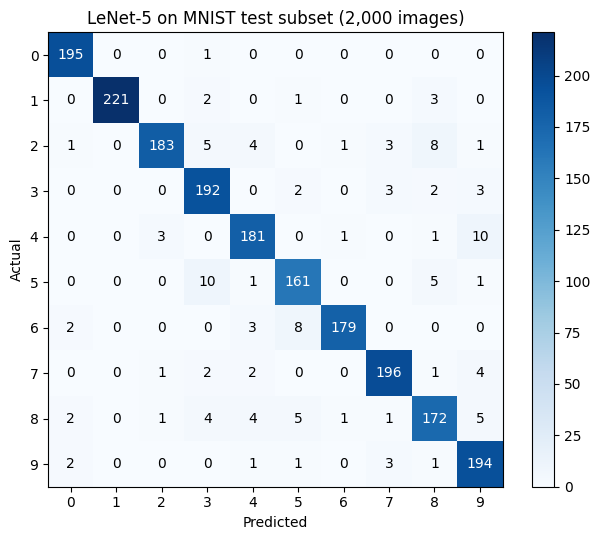

micro: {'accuracy': 0.937, 'precision': 0.937, 'recall': 0.937, 'f1': 0.937}
macro: {'accuracy': 0.937, 'precision': 0.9372, 'recall': 0.9361, 'f1': 0.9361}
recall ต่อ class: [0.995 0.974 0.888 0.95  0.923 0.904 0.932 0.951 0.882 0.96 ] | แย่สุด = digit 8
สับสนบ่อยสุด: จริง 4 → ทาย 9 (10 ครั้ง)


In [8]:
from nnlab import metrics as nm
from nnlab.plotting import plot_confusion

model.eval()
with torch.no_grad():
    logits_te = torch.cat([model(xb) for xb, _ in test_loader])   # logits_te: (2000, 10)
y_pred = logits_te.argmax(dim=1).numpy()                          # y_pred: (2000,)
cm = nm.confusion_matrix(yte, y_pred, n_classes=10)               # cm: (C, C) = (10, 10) แถว actual, คอลัมน์ predicted
print("accuracy =", round(nm.accuracy(yte, y_pred), 4), "| ตรงกับ evaluate():", np.isclose(nm.accuracy(yte, y_pred), history["test_acc"][-1]))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_confusion(cm, ax=ax, title="LeNet-5 on MNIST test subset (2,000 images)")
plt.tight_layout(); plt.show()

print("micro:", {k: round(v, 4) for k, v in nm.multiclass_report(cm, "micro").items()})
print("macro:", {k: round(v, 4) for k, v in nm.multiclass_report(cm, "macro").items()})
c = nm.per_class_counts(cm)
recall_c = c["tp"] / (c["tp"] + c["fn"])                          # (10,)
print("recall ต่อ class:", recall_c.round(3), "| แย่สุด = digit", int(recall_c.argmin()))
off = cm.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"สับสนบ่อยสุด: จริง {i} → ทาย {j} ({off[i, j]} ครั้ง)")

ดูภาพที่ทายผิดพร้อมความมั่นใจ (softmax ของ logits ที่ช่อง class ที่ทาย) — บางภาพเขียนแย่จนคนก็อ่านยาก บางภาพโมเดลมั่นใจผิดๆ

ทายผิด 126 จาก 2000 ภาพ (6.3%)


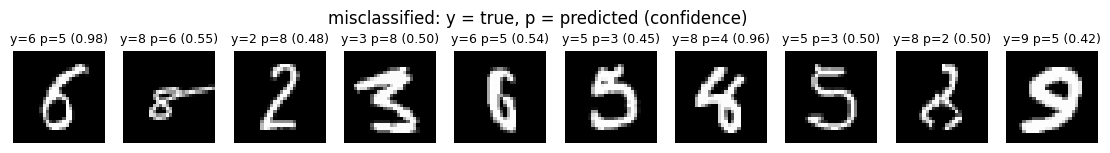

In [9]:
wrong = np.flatnonzero(y_pred != yte)                             # index ของภาพที่ทายผิด
probs = torch.softmax(logits_te, dim=1).numpy()                   # probs: (2000, 10)
print(f"ทายผิด {len(wrong)} จาก {len(yte)} ภาพ ({len(wrong) / len(yte):.1%})")
n_show = min(10, len(wrong))
titles = [f"y={yte[k]} p={y_pred[k]} ({probs[k, y_pred[k]]:.2f})" for k in wrong[:n_show]]
show_images(Xte_u8[wrong[:n_show]], titles, n=n_show, title="misclassified: y = true, p = predicted (confidence)")
plt.show()

## ขั้นที่ 5 · มองเข้าไปข้างใน: filter และ feature map
ใน lab11 เราออกแบบ filter เอง (vertical/horizontal edge) — ใน CNN filter คือ weight ที่ gradient descent เรียนได้
`model.conv1.weight` shape `(6, 1, 5, 5)` คือ filter 6 ตัวขนาด 5×5 — `nnlab.plotting.show_filters` วาดให้ (สว่าง = weight บวก, มืด = ลบ) หลายตัวจะดูคล้าย edge detector ในทิศทางต่างๆ

conv1.weight (6, 1, 5, 5) = 6 filter × 1 channel × 5×5 | bias (6,)


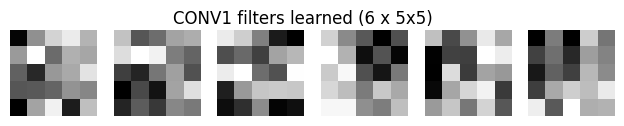

filter 0:
 [[-0.14  0.09  0.2   0.24  0.15]
 [ 0.11  0.28  0.03  0.14  0.13]
 [ 0.01 -0.08  0.1   0.13  0.23]
 [-0.01 -0.    0.02  0.1   0.07]
 [-0.15  0.12  0.25 -0.1   0.17]]


In [10]:
from nnlab.plotting import show_filters, show_feature_maps

w1 = model.conv1.weight.detach().numpy()         # w1: (n_F, C, f, f) = (6, 1, 5, 5)
print("conv1.weight", w1.shape, "= 6 filter × 1 channel × 5×5 | bias", tuple(model.conv1.bias.shape))
show_filters(w1, n_cols=6, title="CONV1 filters learned (6 x 5x5)")
plt.show()
print("filter 0:\n", w1[0, 0].round(2))

**feature map** คือ output ของชั้น conv สำหรับภาพหนึ่ง — channel ละ 1 แผ่น: หลัง CONV1 + ReLU ได้ 6 แผ่น 28×28 และหลัง POOL1 เหลือ 14×14 (ภาพหยาบลงแต่ยังเห็นโครง)
cell นี้ป้อนภาพ test ภาพแรกผ่านทีละชั้นเอง (เหมือนขั้นที่ 2 แต่เป็นภาพจริง) แล้ววาดด้วย `show_feature_maps` — สังเกตว่าแต่ละ channel "สว่าง" ที่ส่วนต่างกันของตัวเลข (ขอบซ้าย, ขอบบน, เส้นเฉียง)

> หมายเหตุ: `show_feature_maps` เดา layout จาก shape (`(C, H, W)` ถ้ามิติแรกเล็กกว่ามิติสุดท้าย) — ใช้ได้กับ 6×28×28 และ 6×14×14 แต่ output ของ CONV2 มี 16 channel ขนาด 10×10 (16 > 10) จะถูกเดาผิดเป็น `(H, W, C)` เราจึงวาด CONV2 เองด้วย matplotlib

label = 7 | หลัง CONV1 (1, 6, 28, 28) | หลัง POOL1 (1, 6, 14, 14) | หลัง CONV2 (1, 16, 10, 10)
ค่าใน feature map ≥ 0 เสมอ (ReLU): a1 min = 0.0 | max = 2.155


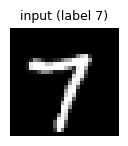

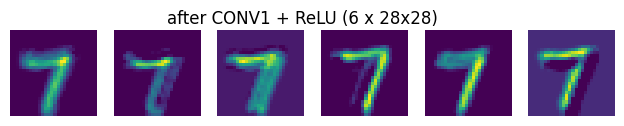

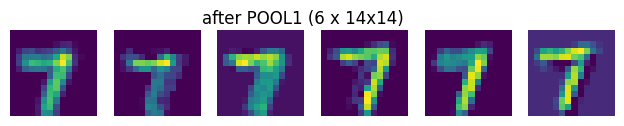

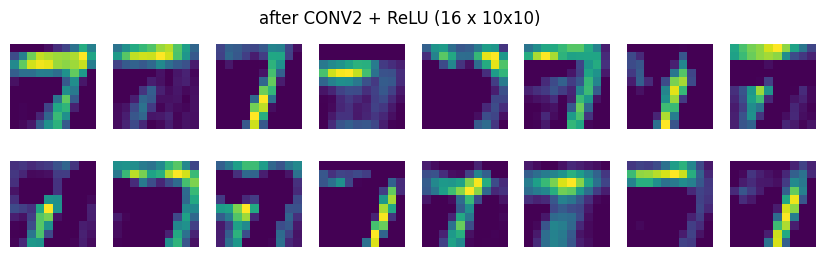

In [11]:
x0 = X_test[0:1]                                  # x0: (1, 1, 28, 28) ภาพ test ภาพแรก (label ด้านล่าง)
with torch.no_grad():
    a1 = F.relu(model.conv1(x0))                  # a1: (1, 6, 28, 28)
    p1 = model.pool(a1)                           # p1: (1, 6, 14, 14)
    a2 = F.relu(model.conv2(p1))                  # a2: (1, 16, 10, 10)
print("label =", int(yte[0]), "| หลัง CONV1", tuple(a1.shape), "| หลัง POOL1", tuple(p1.shape), "| หลัง CONV2", tuple(a2.shape))
print("ค่าใน feature map ≥ 0 เสมอ (ReLU): a1 min =", float(a1.min()), "| max =", round(float(a1.max()), 3))

show_images(Xte_u8[0:1], [f"input (label {yte[0]})"], n=1); plt.show()
show_feature_maps(a1[0].numpy(), n_cols=6, title="after CONV1 + ReLU (6 x 28x28)"); plt.show()
show_feature_maps(p1[0].numpy(), n_cols=6, title="after POOL1 (6 x 14x14)"); plt.show()

fig, axes = plt.subplots(2, 8, figsize=(10.4, 2.8))      # CONV2: วาดเอง (ดูหมายเหตุด้านบน)
for k, ax in enumerate(axes.ravel()):
    ax.imshow(a2[0, k].numpy(), cmap="viridis"); ax.axis("off")
fig.suptitle("after CONV2 + ReLU (16 x 10x10)"); plt.show()

## ขั้นที่ 6 · data augmentation (สไลด์ p.208-210)
เมื่อข้อมูลไม่พอ ("when your data is not enough") เราสร้างภาพใหม่จากภาพเดิมด้วยการแปลงที่**ไม่เปลี่ยน label**: mirroring (p.208), random cropping (p.209), rotation (p.210)
โมเดลจึงเห็นตัวเลขที่เอียงเล็กน้อย/เลื่อนตำแหน่ง/ตัดขอบ และเรียนรู้ที่จะไม่ยึดติดกับตำแหน่งเป๊ะๆ (ลด overfitting)
`torchvision.transforms` มีให้ครบ: `RandomRotation(10)` หมุน ±10°, `RandomAffine(translate=)` เลื่อน, `RandomCrop(28, padding=2)` เติมขอบ 2 pixel แล้วตัดสุ่มกลับเป็น 28×28
กติกาสำคัญ: augment **เฉพาะ training set** — test set ต้องเป็นภาพจริงที่ไม่แต่ง ไม่งั้นคะแนนที่วัดไม่สะท้อนการใช้งานจริง
cell นี้สุ่ม 8 เวอร์ชันของภาพเดียว — ทุกภาพยังเป็นเลขเดิม

augmented (8, 1, 28, 28) | ทุกภาพ label เดิม = 5 | ค่ายังอยู่ใน [0, 1]: True


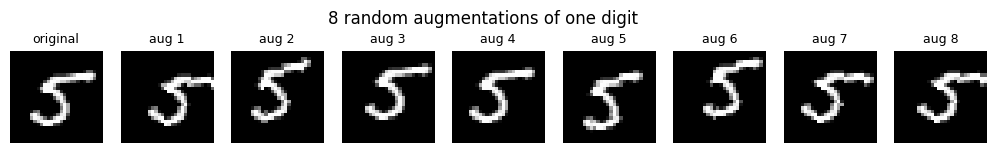

In [12]:
aug = transforms.Compose([
    transforms.RandomRotation(10),                                  # หมุนสุ่ม ±10° (p.210)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),       # เลื่อนสุ่มไม่เกิน 10% ของกว้าง/สูง
    transforms.RandomCrop(28, padding=2),                           # pad 2 แล้ว crop 28×28 ที่ตำแหน่งสุ่ม (p.209)
])
x0 = X_train[0]                                                     # x0: (C, H, W) = (1, 28, 28) — transforms รับทีละภาพ
torch.manual_seed(463)
augmented = torch.stack([aug(x0) for _ in range(8)])                # augmented: (8, 1, 28, 28)
print("augmented", tuple(augmented.shape), "| ทุกภาพ label เดิม =", int(y_train[0]), "| ค่ายังอยู่ใน [0, 1]:", float(augmented.min()) >= 0 and float(augmented.max()) <= 1)
imgs = np.concatenate([x0[None, 0].numpy(), augmented[:, 0].numpy()])   # imgs: (9, 28, 28)
show_images(imgs, ["original"] + [f"aug {k + 1}" for k in range(8)], n=9, title="8 random augmentations of one digit")
plt.show()

### ทำไม mirroring ใช้กับตัวเลขไม่ได้
สไลด์ p.208 ใช้ mirroring กับภาพแมว — แมวกลับซ้ายขวายังเป็นแมว แต่ตัวเลขกลับซ้ายขวา**ไม่ใช่ตัวเลขเดิม** (3 กลับด้านไม่ใช่ตัวอักษรใดเลย, 2 กับ 5 ดูคล้ายกันเมื่อกลับ)
augmentation ต้องเลือกให้ตรงกับ "อะไรที่ไม่เปลี่ยนความหมายในโจทย์นี้" — ไม่มีสูตรตายตัว
ส่วนการใช้จริงกับ `DataLoader`: ห่อ dataset ให้เรียก transform ใน `__getitem__` — ภาพจะถูกสุ่มใหม่**ทุกครั้งที่ถูกดึง** ทุก epoch จึงเห็นภาพไม่ซ้ำกัน (ลองเทรนเป็นแบบฝึกหัด)
**lab13** จะใช้แนวคิดนี้กับภาพสีจริงจากไฟล์ในโฟลเดอร์ พร้อม early stopping และ transfer learning ด้วย ResNet-18 ที่มี pretrained weights

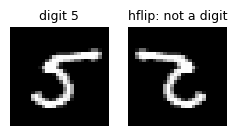

aug_ds[0] สองครั้งได้ภาพต่างกัน: True | batch จาก aug_loader: (64, 1, 28, 28) | test_loader ยังใช้ภาพจริงไม่แต่ง


In [13]:
flipped = transforms.functional.hflip(x0)                          # (1, 28, 28) กลับซ้าย-ขวา
show_images(np.stack([x0[0].numpy(), flipped[0].numpy()]), [f"digit {int(y_train[0])}", "hflip: not a digit"], n=2)
plt.show()

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform):
        self.X, self.y, self.transform = X, y, transform            # X: (m, 1, 28, 28) | y: (m,)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.transform(self.X[i]), self.y[i]                 # สุ่ม transform ใหม่ทุกครั้งที่ถูกเรียก

aug_ds = AugmentedDataset(X_train, y_train, aug)
xa, _ = aug_ds[0]; xb2, _ = aug_ds[0]
aug_loader = DataLoader(aug_ds, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(463))
xb_aug, yb_aug = next(iter(aug_loader))                            # xb_aug: (64, 1, 28, 28)
print("aug_ds[0] สองครั้งได้ภาพต่างกัน:", not torch.equal(xa, xb2), "| batch จาก aug_loader:", tuple(xb_aug.shape), "| test_loader ยังใช้ภาพจริงไม่แต่ง")

## ขั้นที่ 7 · classic CNN: LeNet-5, AlexNet, VGG-16, ResNet (สไลด์ p.201-207)
| network | ปี | input | parameters | จุดเด่น | สไลด์ |
|---|---|---|---|---|---|
| LeNet-5 | 1998 | 32×32×1 | ~60k | CONV → POOL → CONV → POOL → FC → FC → Softmax; average pooling | p.202 |
| AlexNet | 2012 | 227×227×3 | ~60M | เหมือน LeNet แต่ใหญ่กว่ามาก: filter 11×11 stride 4 ชั้นแรก, ReLU, max pooling, FC 4096 ×2, 1,000 class (ImageNet) | p.203 |
| VGG-16 | 2014 | 224×224×3 | ~138M | ใช้แต่ conv 3×3 s=1 same padding + pool 2×2 s=2; channel เพิ่ม 64 → 128 → 256 → 512 ขณะที่ H, W ลดครึ่ง | p.204 |
| ResNet | 2015 | 224×224×3 | 11.7M (ResNet-18) | **residual block** มี skip connection $a^{[l+2]} = g(z^{[l+2]} + a^{[l]})$ ทำให้ซ้อนได้เป็นร้อยชั้น | p.205-207 |

`torchvision.models` มีทั้งหมดนี้ให้ — `weights=None` สร้างโมเดลด้วย weight สุ่ม (ไม่ดาวน์โหลดอะไร) พอให้เราอ่านโครงสร้างและนับ parameter
cell นี้พิมพ์โครงสร้าง AlexNet กับ ResNet-18 แบบย่อ (1,500 ตัวอักษรแรก) — สังเกต `Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4))` ของ AlexNet ตรงกับสไลด์ p.203 และ `BasicBlock` ของ ResNet ที่มี conv 2 ชั้นต่อ block

In [14]:
import torchvision

alex  = torchvision.models.alexnet(weights=None)     # weights=None → สุ่ม ไม่ต้องดาวน์โหลด
vgg   = torchvision.models.vgg16(weights=None)
res18 = torchvision.models.resnet18(weights=None)
print(f"LeNet-5   {n_params:>13,} parameters  (สไลด์ p.202: ~60k)")
print(f"AlexNet   {count_parameters(alex):>13,} parameters  (สไลด์ p.203: ~60M)")
print(f"VGG-16    {count_parameters(vgg):>13,} parameters")
print(f"ResNet-18 {count_parameters(res18):>13,} parameters")
del vgg                                              # คืน memory (~0.5 GB)

print("\n===== AlexNet =====\n" + str(alex)[:1500] + "\n...")
print("\n===== ResNet-18 =====\n" + str(res18)[:1500] + "\n...")
n_blocks = sum(isinstance(m, torchvision.models.resnet.BasicBlock) for m in res18.modules())
print(f"\nResNet-18 มี BasicBlock (residual block) {n_blocks} block × conv 2 ชั้น + conv แรก + FC = 18 ชั้นที่มี weight")

LeNet-5          61,706 parameters  (สไลด์ p.202: ~60k)
AlexNet      61,100,840 parameters  (สไลด์ p.203: ~60M)
VGG-16      138,357,544 parameters
ResNet-18    11,689,512 parameters

===== AlexNet =====
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, c

### residual block (สไลด์ p.205-207)
block ปกติ: $z^{[l+1]} = W^{[l+1]} a^{[l]} + b^{[l+1]},\ a^{[l+1]} = g(z^{[l+1]}),\ z^{[l+2]} = W^{[l+2]} a^{[l+1]} + b^{[l+2]},\ a^{[l+2]} = g(z^{[l+2]})$
residual block เพิ่ม **shortcut**: $a^{[l+2]} = g(z^{[l+2]} + a^{[l]})$ — บวก input ของ block เข้าไปก่อน activation สุดท้าย
ทำไมช่วย (p.207): ในทางทฤษฎี network ยิ่งลึก training error ยิ่งควรลด แต่ในความเป็นจริง plain network ที่ลึกมาก error กลับ**เพิ่ม** เพราะเทรนยาก (gradient เล็กลง/ระเบิดเมื่อผ่านหลายชั้น)
กับ shortcut ถ้าชั้นใหม่ยังไม่มีประโยชน์ network แค่ทำให้ $W \approx 0$ แล้ว $a^{[l+2]} = g(a^{[l]}) = a^{[l]}$ (identity) — การเพิ่มชั้นจึง**ไม่ทำให้แย่ลง** และ gradient ไหลผ่าน shortcut ได้ตรงๆ
`nnlab.torch_models.ResidualBlock` คือเวอร์ชัน fully-connected ของ p.205 — cell นี้เดินทีละบรรทัดให้เห็น `relu(z2 + a)` และตรวจว่าเมื่อ weight เป็น 0 block คืน `a` เดิม

In [15]:
from nnlab.torch_models import ResidualBlock

block = ResidualBlock(4)                          # fc1, fc2: Linear(4, 4)
a = torch.relu(torch.randn(2, 4))                 # a[l]: (N, n) = (2, 4)
with torch.no_grad():                             # แค่ดูค่า ไม่ต้องเก็บ graph สำหรับ backward
    z1 = block.fc1(a); a1 = torch.relu(z1)        # z[l+1], a[l+1]: (2, 4)
    z2 = block.fc2(a1)                            # z[l+2]: (2, 4)
    out_plain = torch.relu(z2)                    # block ปกติ:    a[l+2] = g(z[l+2])
    out_res   = torch.relu(z2 + a)                # residual:      a[l+2] = g(z[l+2] + a[l])   (p.205)
    assert torch.allclose(block(a), out_res)
    print("a[l]            :", a[0].numpy().round(3))
    print("plain  g(z2)    :", out_plain[0].numpy().round(3))
    print("residual g(z2+a):", out_res[0].numpy().round(3), "= block(a) ✓")

    for p in block.parameters():
        nn.init.zeros_(p)                         # ชั้นที่ "ยังไม่เรียนอะไร"
    print("weights = 0 → block(a) == a (identity):", torch.allclose(block(a), a), "| plain block ที่ weight = 0 ให้", torch.relu(torch.zeros(1, 4))[0].numpy(), "= ข้อมูลหายหมด")

a[l]            : [0.554 0.    0.819 0.   ]
plain  g(z2)    : [0.    0.286 0.11  0.   ]
residual g(z2+a): [0.377 0.286 0.929 0.   ] = block(a) ✓
weights = 0 → block(a) == a (identity): True | plain block ที่ weight = 0 ให้ [0. 0. 0. 0.] = ข้อมูลหายหมด


## ขั้นที่ 8 · บันทึกและโหลดโมเดล
โมเดลที่เทรนแล้วคือ **parameter** ของมัน — `model.state_dict()` คือ dict {ชื่อ → tensor} เราบันทึกด้วย `torch.save` แล้วโหลดกลับเข้าโมเดล**ใหม่ที่มี architecture เดียวกัน**ด้วย `load_state_dict`
cell นี้บันทึกลงโฟลเดอร์ชั่วคราว สร้าง `LeNet5()` ใหม่ (weight สุ่ม ทายมั่ว) โหลด state_dict เข้าไป แล้ว assert ว่าทำนาย test set ได้ตรงกับโมเดลเดิมทุกภาพ

สำหรับการเทรนแบบเต็ม (60,000 ภาพ หลาย epoch, augmentation, บันทึกผล/กราฟอัตโนมัติ) ใช้ script บน terminal แทน notebook:
`uv run python scripts/train_cnn.py --epochs 3 --augment` — ผลลัพธ์อยู่ใน `runs/<timestamp>_lenet5_mnist/` (model.pt, metrics.json, confusion.png, filters.png) — ไม่ต้องรันใน lab นี้

In [16]:
import tempfile, pathlib

tmp = pathlib.Path(tempfile.mkdtemp())
path = tmp / "lenet5_mnist.pt"
torch.save(model.state_dict(), path)                         # เก็บเฉพาะ parameter
print("บันทึก", path.name, f"({path.stat().st_size / 1024:.0f} KB)")
print("state_dict keys:", list(model.state_dict().keys()))

fresh = LeNet5()                                             # โมเดลใหม่ weight สุ่ม
fresh.eval()
with torch.no_grad():
    before = fresh(X_test[:8]).argmax(dim=1).tolist()
fresh.load_state_dict(torch.load(path, weights_only=True))   # โหลด parameter เข้าไป (architecture ต้องตรงกัน)
with torch.no_grad():
    p_fresh = fresh(X_test).argmax(dim=1).numpy()            # (2000,)
assert np.array_equal(p_fresh, y_pred), "โมเดลที่โหลดต้องทำนายเหมือนเดิมทุกภาพ"
print("ก่อนโหลด (weight สุ่ม) 8 ภาพแรกทาย:", before, "| จริง:", yte[:8].tolist())
print("หลังโหลด: prediction ตรงกับโมเดลเดิมทั้ง", len(y_pred), "ภาพ ✓")

บันทึก lenet5_mnist.pt (245 KB)
state_dict keys: ['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']
ก่อนโหลด (weight สุ่ม) 8 ภาพแรกทาย: [6, 6, 6, 6, 6, 6, 6, 6] | จริง: [7, 4, 9, 6, 3, 0, 8, 0]
หลังโหลด: prediction ตรงกับโมเดลเดิมทั้ง 2000 ภาพ ✓


## ขั้นที่ 9 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/torch_models.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (LeNet5 และ TorchTrainer) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/torch_models.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

`TorchTrainer` คือ training loop ของขั้นที่ 3 ที่จัดเป็นคลาส (interface เดียวกับ `Perceptron` / `NeuralNetwork`: `fit`, `predict`, `evaluate`, `history_`) — เปิด `src/nnlab/torch_models.py` จะเห็น 5 ขั้นเดิมใน `fit_loader`
เราเทรน `nnlab.torch_models.LeNet5` 1 epoch บน subset เดียวกันแล้วเทียบ test accuracy กับ loop ของเราหลัง epoch แรก (ค่าใกล้กัน — ไม่เท่ากันเป๊ะเพราะ weight เริ่มต้นและลำดับ batch ต่างกัน)
ระบุ `device="cpu"` เพื่อให้ผลทำซ้ำได้ (ค่า default จะเลือก GPU/MPS ถ้ามี)

In [17]:
from nnlab.torch_models import TorchTrainer

trainer = TorchTrainer(LeNet5_nn(), loss="ce", optimizer="adam", lr=1e-3, epochs=1, batch_size=64, device="cpu")
with Timer() as t2:
    trainer.fit(X_train, ytr, X_test, yte)                    # รับ tensor (m, 1, 28, 28) หรือ numpy ก็ได้
rep = trainer.evaluate(X_test, yte)                           # classification_summary: accuracy + macro/micro
print(f"TorchTrainer 1 epoch ({t2.elapsed:.1f} s): test accuracy {rep['accuracy']:.4f} | macro F1 {rep['macro_f1']:.4f}")
print(f"loop ของเราหลัง epoch 1     : test accuracy {history['test_acc'][0]:.4f}")
print("history_ ของ trainer:", {k: [round(v, 4) for v in vals] for k, vals in trainer.history_.items()})
print(trainer)

TorchTrainer 1 epoch (1.1 s): test accuracy 0.8895 | macro F1 0.8884
loop ของเราหลัง epoch 1     : test accuracy 0.8740
history_ ของ trainer: {'cost': [0.9374], 'val_cost': [0.3547], 'val_acc': [0.8895]}
TorchTrainer(LeNet5, loss=ce, optimizer=adam, lr=0.001, epochs=1, batch_size=64, device=cpu)


## ★ Key Takeaways
- ภาพเข้า torch เป็น `float32 (N, 1, 28, 28)` ช่วง [0, 1] และ label เป็น `long (N,)`; `TensorDataset` + `DataLoader(batch_size=64, shuffle=True)` หั่น mini-batch ให้ — augmentation ทำใน `__getitem__` เฉพาะ training set
- LeNet-5 = CONV(6, 5×5) → POOL → CONV(16, 5×5) → POOL → 400 → 120 → 84 → 10 รวม ≈ 62k parameter; `nn.Module` ต้องมี `__init__` (ประกาศชั้น) และ `forward` (ลำดับคำนวณ) — backward ได้ฟรี
- training loop 5 ขั้น: `zero_grad → forward → loss → backward → step`; `CrossEntropyLoss` รับ **logits** (ห้าม softmax ใน forward) กับ label เป็นเลข class; loss เริ่มที่ ln 10 ≈ 2.30
- ประเมินด้วย confusion matrix 10×10 + micro/macro จาก lab10 และดูภาพที่ทายผิด; filter ของ CONV1 กับ feature map แสดงว่าโมเดลเรียน edge detector ได้เอง
- AlexNet (~60M) และ VGG-16 (~138M) คือ LeNet ที่ใหญ่ขึ้น; ResNet ใช้ residual block `a[l+2] = g(z[l+2] + a[l])` ให้เพิ่มชั้นแล้วไม่แย่ลง (weight = 0 → identity)
- บันทึกโมเดล = บันทึก `state_dict`; โหลดกลับเข้า architecture เดียวกันได้ prediction เหมือนเดิมทุกภาพ; `TorchTrainer` คือ loop เดิมที่ห่อเป็นคลาสให้ใช้ interface เดียวกับโมเดล numpy

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [18]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 12.1 · LeNet-5 แบบ average pooling มี parameter เท่าเดิมไหม
**เป้าหมาย:** สร้าง `nnlab.torch_models.LeNet5` เวอร์ชัน average pooling (LeNet-5 ดั้งเดิม สไลด์ p.202) แล้วนับ parameter เทียบกับแบบ max pooling — ต้องเท่ากันเพราะ pooling ไม่มี parameter (lab11 ขั้นที่ 5)

**ขั้นตอน**
1. เขียน `make_lenet_avg()` ให้คืน `LeNet5_nn(pool="avg")` (คลาสจาก nnlab ที่ import ไว้ในขั้นที่ 2)
2. กำหนด `n_avg` = จำนวน parameter ของ `make_lenet_avg()` ด้วย `count_parameters`
3. กำหนด `n_max` = จำนวน parameter ของ `LeNet5_nn()` (แบบ max pooling) แล้วพิมพ์เทียบกัน

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `LeNet5_nn` คือ `nnlab.torch_models.LeNet5` มี argument `pool="max"` หรือ `"avg"` (ดู docstring ใน `src/nnlab/torch_models.py`)
- `count_parameters(model)` นับ `numel` ของทุก parameter ที่ `requires_grad` — เขียนเองก็ได้: `sum(p.numel() for p in model.parameters())`
</details>

In [19]:
# --- แบบฝึกหัด 12.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def make_lenet_avg():
    """คืน nnlab LeNet5 ที่ใช้ average pooling แทน max pooling"""
    raise NotImplementedError("ยังไม่ได้ทำ")

n_avg = ...              # TODO: count_parameters(make_lenet_avg())
n_max = ...              # TODO: count_parameters ของ LeNet5_nn() แบบ max pooling
# print(make_lenet_avg()); print("avg:", n_avg, "| max:", n_max)

In [20]:
# --- ตรวจคำตอบ 12.1 (รันได้ทันที ไม่ต้องแก้) ---
check("12.1 make_lenet_avg() มี AvgPool2d 2 ชั้น และไม่มี MaxPool2d", lambda: sum(isinstance(m, nn.AvgPool2d) for m in make_lenet_avg().modules()) == 2 and not any(isinstance(m, nn.MaxPool2d) for m in make_lenet_avg().modules()), hint='LeNet5_nn(pool="avg")')
check_shape("12.1 make_lenet_avg()(batch 2 ภาพ) → (2, 10)", lambda: make_lenet_avg()(torch.zeros(2, 1, 28, 28)), (2, 10))
check_close("12.1 n_avg = 61,706 (สไลด์ p.202: ~60k)", lambda: n_avg, 61706, hint="count_parameters(make_lenet_avg())")
check_close("12.1 n_max = ผลรวม numel ของ LeNet5_nn().parameters()", lambda: n_max, sum(p.numel() for p in LeNet5_nn().parameters()), hint="count_parameters(LeNet5_nn()) — ค่าเดียวกับ n_avg เพราะ pooling ไม่มี parameter")

⏳ 12.1 make_lenet_avg() มี AvgPool2d 2 ชั้น และไม่มี MaxPool2d: ยังไม่ได้ทำ
⏳ 12.1 make_lenet_avg()(batch 2 ภาพ) → (2, 10): ยังไม่ได้ทำ
⏳ 12.1 n_avg = 61,706 (สไลด์ p.202: ~60k): ยังไม่ได้ทำ
⏳ 12.1 n_max = ผลรวม numel ของ LeNet5_nn().parameters(): ยังไม่ได้ทำ


False

### แบบฝึกหัด 12.2 · augmentation pipeline ของตัวเอง
**เป้าหมาย:** เขียน `make_aug_dataset(X, y)` ที่ประกอบ transform ใหม่ (หมุนสุ่ม ±10° แล้ว pad 2 pixel + crop สุ่มกลับเป็น 28×28 — สไลด์ p.209-210) แล้วห่อเป็น `AugmentedDataset` จากขั้นที่ 6 เพื่อใช้กับ DataLoader

**ขั้นตอน**
1. สร้าง `transforms.Compose([...])` ที่มี `transforms.RandomRotation(10)` ตามด้วย `transforms.RandomCrop(28, padding=2)` (ลำดับนี้)
2. คืน `AugmentedDataset(X, y, <transform ที่สร้าง>)` — คลาสนี้เรียก transform ใหม่ทุกครั้งใน `__getitem__`
3. ทดลอง: `ds = make_aug_dataset(X_train, y_train)` แล้วดึง `ds[0]` สองครั้ง — ต้องได้ภาพต่างกันแต่ shape `(1, 28, 28)` และค่าใน [0, 1] เท่าเดิม

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- ดูตัวแปร `aug` ในขั้นที่ 6 — ต่างกันแค่ตัด `RandomAffine` ออก
- `AugmentedDataset` เก็บ `(X, y, transform)` ไว้ แล้วคืน `(transform(X[i]), y[i])` เมื่อถูกเรียก — ไม่ต้องเขียนคลาสใหม่
</details>

In [21]:
# --- แบบฝึกหัด 12.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def make_aug_dataset(X, y):
    """X: (m, 1, 28, 28) float [0, 1], y: (m,) → AugmentedDataset ที่ transform = Compose([RandomRotation(10), RandomCrop(28, padding=2)])"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ds_rc = make_aug_dataset(X_train, y_train)
# imgs = torch.stack([ds_rc[0][0] for _ in range(6)])[:, 0].numpy(); show_images(imgs, [f"draw {k + 1}" for k in range(6)], n=6); plt.show()

In [22]:
# --- ตรวจคำตอบ 12.2 (รันได้ทันที ไม่ต้องแก้) ---
def _ds():
    return make_aug_dataset(X_train, y_train)

def _two_draws_differ():
    d = _ds()
    return not torch.equal(d[0][0], d[0][0])

check("12.2 transform = Compose([RandomRotation, RandomCrop]) ตามลำดับ", lambda: [type(t).__name__ for t in _ds().transform.transforms] == ["RandomRotation", "RandomCrop"], hint="transforms.Compose([transforms.RandomRotation(10), transforms.RandomCrop(28, padding=2)])")
check("12.2 RandomRotation ±10° และ RandomCrop 28 padding 2", lambda: tuple(_ds().transform.transforms[0].degrees) == (-10.0, 10.0) and tuple(_ds().transform.transforms[1].size) == (28, 28) and _ds().transform.transforms[1].padding == 2, hint="RandomRotation(10) หมายถึง (−10°, +10°); RandomCrop(28, padding=2)")
check_shape("12.2 ds[0] คืนภาพ (1, 28, 28)", lambda: _ds()[0][0], (1, 28, 28), hint="RandomCrop(28, padding=2) คืน 28×28 เสมอ")
check("12.2 label ของ ds[7] = y_train[7] และ len(ds) = len(X_train)", lambda: int(_ds()[7][1]) == int(y_train[7]) and len(_ds()) == len(X_train), hint="AugmentedDataset(X, y, transform) — อย่าลืมส่ง y")
check("12.2 ดึงภาพเดียวกันสองครั้งได้ต่างกัน (สุ่มใหม่ทุกครั้ง)", _two_draws_differ, hint="ถ้าเท่ากัน แสดงว่า transform ไม่สุ่ม หรือ __getitem__ ไม่ได้เรียก transform")
check("12.2 ค่ายังอยู่ใน [0, 1]", lambda: 0.0 <= float(_ds()[0][0].min()) and float(_ds()[0][0].max()) <= 1.0, hint="หมุน/crop ไม่เปลี่ยนช่วงค่า — ถ้าเกิน แสดงว่าใส่ Normalize หรือคูณอะไรเพิ่ม")

⏳ 12.2 transform = Compose([RandomRotation, RandomCrop]) ตามลำดับ: ยังไม่ได้ทำ
⏳ 12.2 RandomRotation ±10° และ RandomCrop 28 padding 2: ยังไม่ได้ทำ
⏳ 12.2 ds[0] คืนภาพ (1, 28, 28): ยังไม่ได้ทำ
⏳ 12.2 label ของ ds[7] = y_train[7] และ len(ds) = len(X_train): ยังไม่ได้ทำ
⏳ 12.2 ดึงภาพเดียวกันสองครั้งได้ต่างกัน (สุ่มใหม่ทุกครั้ง): ยังไม่ได้ทำ
⏳ 12.2 ค่ายังอยู่ใน [0, 1]: ยังไม่ได้ทำ


False

### แบบฝึกหัด 12.3 · LeNet-5 ที่มี BatchNorm หลัง conv ทุกชั้น
**เป้าหมาย:** ประกอบ LeNet-5 ใหม่เป็น `nn.Sequential` โดยแทรก `nn.BatchNorm2d` หลัง conv แต่ละชั้น (ก่อน ReLU) — BatchNorm ทำให้ activation ของแต่ละ channel มี mean 0 / std 1 ต่อ mini-batch ช่วยให้ loss ลดเร็วขึ้น

**ขั้นตอน**
1. เรียงชั้นใน `nn.Sequential`: `Conv2d(1, 6, 5, padding=2)` → `BatchNorm2d(6)` → `ReLU` → `MaxPool2d(2, 2)`
2. ต่อด้วย `Conv2d(6, 16, 5)` → `BatchNorm2d(16)` → `ReLU` → `MaxPool2d(2, 2)`
3. ปิดท้าย `Flatten` → `Linear(400, 120)` → `ReLU` → `Linear(120, 84)` → `ReLU` → `Linear(84, 10)` (logits ไม่มี softmax)
4. ทดลอง: `make_bn_lenet()(torch.zeros(4, 1, 28, 28)).shape` ต้องเป็น `(4, 10)` และ parameter ต้องมากกว่า 61,706 อยู่ 44 ตัว (γ, β ของ BN 6 + 16 channel)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `nn.Sequential(nn.Conv2d(...), nn.BatchNorm2d(6), nn.ReLU(), nn.MaxPool2d(2, 2), ...)` — ส่งชั้นเรียงตามลำดับเป็น argument
- `nn.Flatten()` ทำหน้าที่เดียวกับ `torch.flatten(x, start_dim=1)` ใน `forward` ของ LeNet5 ขั้นที่ 2
- ตอนเทรนโมเดลที่มี BN ต้องเรียก `model.train()` / `model.eval()` ให้ถูก — `TorchTrainer` ทำให้แล้ว (ขั้นที่ 9)
</details>

In [23]:
# --- แบบฝึกหัด 12.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def make_bn_lenet():
    """LeNet-5 เป็น nn.Sequential ที่มี BatchNorm2d หลัง conv ทุกชั้น: รับ (N, 1, 28, 28) คืน logits (N, 10)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# bn_model = make_bn_lenet(); print(bn_model); print(count_parameters(bn_model))

In [24]:
# --- ตรวจคำตอบ 12.3 (รันได้ทันที ไม่ต้องแก้) ---
def _leaves():                                            # module ระดับล่างสุด เรียงตามลำดับที่ประกาศ
    return [m for m in make_bn_lenet().modules() if len(list(m.children())) == 0]

def _bn_follows_conv():
    L = _leaves()
    return all(isinstance(L[i + 1], nn.BatchNorm2d) for i, m in enumerate(L[:-1]) if isinstance(m, nn.Conv2d))

check_shape("12.3 make_bn_lenet()(batch 4 ภาพ) → (4, 10)", lambda: make_bn_lenet()(torch.zeros(4, 1, 28, 28)), (4, 10), hint="เดิน shape: 28 → 28 (pad 2) → 14 → 10 → 5 → flatten 400 → 120 → 84 → 10")
check("12.3 มี BatchNorm2d 2, Conv2d 2, Linear 3 ชั้น", lambda: [sum(isinstance(m, T) for m in _leaves()) for T in (nn.BatchNorm2d, nn.Conv2d, nn.Linear)] == [2, 2, 3], hint="BatchNorm2d หนึ่งตัวต่อ conv หนึ่งชั้น")
check("12.3 BatchNorm2d ตามหลัง Conv2d ทันที (ก่อน ReLU)", _bn_follows_conv, hint="ลำดับใน block: Conv2d → BatchNorm2d → ReLU → MaxPool2d")
check("12.3 BatchNorm2d ตัวแรก 6 channel ตัวที่สอง 16", lambda: [m.num_features for m in _leaves() if isinstance(m, nn.BatchNorm2d)] == [6, 16], hint="num_features ของ BN = out_channels ของ conv ก่อนหน้า")
check_close("12.3 parameters = 61,706 + 44 = 61,750", lambda: count_parameters(make_bn_lenet()), 61750, hint="BatchNorm2d(C) มี parameter 2C ตัว (γ, β) — ถ้าได้ 61,706 แสดงว่ายังไม่ได้ใส่ BN")

⏳ 12.3 make_bn_lenet()(batch 4 ภาพ) → (4, 10): ยังไม่ได้ทำ
⏳ 12.3 มี BatchNorm2d 2, Conv2d 2, Linear 3 ชั้น: ยังไม่ได้ทำ
⏳ 12.3 BatchNorm2d ตามหลัง Conv2d ทันที (ก่อน ReLU): ยังไม่ได้ทำ
⏳ 12.3 BatchNorm2d ตัวแรก 6 channel ตัวที่สอง 16: ยังไม่ได้ทำ
⏳ 12.3 parameters = 61,706 + 44 = 61,750: ยังไม่ได้ทำ


False

### แบบฝึกหัด 12.4 · ฟังก์ชันเทรน-แล้ววัด เพื่อเทียบสถาปัตยกรรม
**เป้าหมาย:** เขียน `train_and_score(model, epochs)` ที่เทรนโมเดลใดก็ได้ด้วย `TorchTrainer` บน subset ของ lab นี้แล้วคืน test accuracy — ใช้เทียบ LeNet-5 ธรรมดากับแบบมี BatchNorm จาก 12.3 (เกณฑ์ ≥ 0.85)

**ขั้นตอน**
1. สร้าง `TorchTrainer(model, loss="ce", optimizer="adam", lr=1e-3, epochs=epochs, batch_size=64, device="cpu")` (เหมือนขั้นที่ 9)
2. เรียก `.fit(X_train, ytr)` — tensor `(m, 1, 28, 28)` กับ label numpy ใช้ได้เลย
3. คืน `float(trainer.evaluate(X_test, yte)["accuracy"])`
4. ทดลอง: `train_and_score(LeNet5_nn(), EX_EPOCHS)` แล้วลอง `make_bn_lenet()` จาก 12.3 — BN ควรได้สูงกว่าด้วย epoch เท่ากัน

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- ดู cell ของขั้นที่ 9: `trainer = TorchTrainer(LeNet5_nn(), loss="ce", ...); trainer.fit(X_train, ytr, X_test, yte); rep = trainer.evaluate(X_test, yte)` — ฟังก์ชันนี้คือ 3 บรรทัดนั้นที่รับ `model` และ `epochs` เป็น argument
- `evaluate` คืน dict มี key `accuracy`, `macro_f1`, ... — เลือกเฉพาะ accuracy
- อย่าส่ง `X_test` ให้ `fit` เป็นชุด train — test set ต้องใช้วัดผลเท่านั้น
</details>

In [25]:
# --- แบบฝึกหัด 12.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def train_and_score(model, epochs):
    """เทรน model ด้วย TorchTrainer (ce, adam, lr=1e-3, batch 64, cpu) บน X_train/ytr แล้วคืน test accuracy บน X_test/yte เป็น float"""
    raise NotImplementedError("ยังไม่ได้ทำ")

EX_EPOCHS = 3 if FAST else 2          # FAST มีภาพน้อยกว่า จึงให้ epoch มากขึ้นหน่อย
# torch.manual_seed(463); print("LeNet-5:", train_and_score(LeNet5_nn(), EX_EPOCHS))

In [26]:
# --- ตรวจคำตอบ 12.4 (รันได้ทันที ไม่ต้องแก้) ---
_scores = {}
def _score(name, make_model):                             # เทรนแต่ละสถาปัตยกรรมครั้งเดียวแล้วจำผลไว้
    if name not in _scores:
        torch.manual_seed(463)
        _scores[name] = train_and_score(make_model(), EX_EPOCHS)
    return _scores[name]

check("12.4 คืนค่าเป็นตัวเลขในช่วง [0, 1]", lambda: 0.0 <= float(_score("LeNet-5", LeNet5_nn)) <= 1.0, hint="คืน rep['accuracy'] จาก trainer.evaluate(X_test, yte) ไม่ใช่ dict ทั้งก้อน")
check("12.4 LeNet5_nn(): test accuracy ≥ 0.85", lambda: _score("LeNet-5", LeNet5_nn) >= 0.85, hint="ตรวจว่า fit ด้วย X_train/ytr (ไม่ใช่ X_test) ครบ epochs ที่รับมา และ lr=1e-3")
check("12.4 make_bn_lenet() จาก 12.3: test accuracy ≥ 0.85 (ต้องทำ 12.3 ก่อน)", lambda: _score("LeNet-5 + BN", make_bn_lenet) >= 0.85, hint="ถ้า 12.3 ผ่านแล้วแต่ข้อนี้ต่ำ ตรวจว่า TorchTrainer ได้รับ model ที่ส่งเข้ามา ไม่ใช่สร้างใหม่เอง")
for _name, _acc in _scores.items():
    print(f"   {_name}: test accuracy = {_acc:.4f} ({EX_EPOCHS} epoch, {len(train_ds):,} ภาพ)")

⏳ 12.4 คืนค่าเป็นตัวเลขในช่วง [0, 1]: ยังไม่ได้ทำ
⏳ 12.4 LeNet5_nn(): test accuracy ≥ 0.85: ยังไม่ได้ทำ
⏳ 12.4 make_bn_lenet() จาก 12.3: test accuracy ≥ 0.85 (ต้องทำ 12.3 ก่อน): ยังไม่ได้ทำ


### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [27]:
summary()

สรุป: PASS 0/18 · FAIL 0 · ยังไม่ได้ทำ 18


{'pass': 0, 'fail': 0, 'todo': 18, 'error': 0}